# Actividad 3 – Modelos Naïve Bayes y Support Vector Machines

## 1. Definición del problema y contexto

### 1.1 Contexto del problema

La fuga de clientes (*churn*) es uno de los principales desafíos en la industria de telecomunicaciones, ya que la pérdida de clientes tiene un impacto directo en los ingresos y en la estabilidad del negocio.  
En este contexto, los modelos de **Machine Learning supervisado** permiten identificar patrones asociados al abandono del servicio y apoyar la toma de decisiones orientadas a la retención de clientes.

El presente análisis aborda un problema de **clasificación binaria desbalanceada**, donde el objetivo es predecir si un cliente abandonará el servicio (`Churn = 1`) o permanecerá (`Churn = 0`), a partir de variables demográficas, contractuales y de consumo.

---

### 1.2 Objetivo de la actividad

El objetivo de esta actividad es **desarrollar, optimizar y comparar modelos de clasificación avanzados**, específicamente **Naïve Bayes** y **Support Vector Machines (SVM)**, evaluando su desempeño predictivo y analizando sus ventajas y limitaciones en un problema real de churn.

En particular, se busca:

- Evaluar el desempeño de **Naïve Bayes** bajo el supuesto de independencia condicional.
- Comparar modelos **SVM lineales y no lineales (kernel RBF)**.
- Analizar el impacto del **desbalance de clases** y el uso de técnicas como `class_weight="balanced"`.
- Utilizar métricas adecuadas para clasificación desbalanceada, tales como **F1-score**, **ROC-AUC** y **Precision–Recall AUC**.
- Analizar el compromiso entre **desempeño, interpretabilidad y costo computacional**.

---

### 1.3 Metodología general

La metodología seguida en esta actividad considera las siguientes etapas:

1. **Carga y limpieza del dataset**, incluyendo el tratamiento de valores faltantes y la codificación de la variable objetivo.
2. **Construcción de pipelines de preprocesamiento**, separando variables numéricas y categóricas, aplicando imputación, escalamiento y codificación *one-hot*.
3. **Entrenamiento y optimización de modelos**, utilizando validación cruzada estratificada y búsqueda de hiperparámetros.
4. **Evaluación de desempeño**, mediante métricas y visualizaciones apropiadas para clasificación binaria desbalanceada.
5. **Análisis crítico de resultados**, considerando supuestos estadísticos, costo computacional e implicancias desde una perspectiva de negocio.

A continuación, se presenta la implementación del código correspondiente a cada una de estas etapas, junto con la interpretación de los resultados obtenidos.


In [16]:
import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, make_scorer
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)


## 2. Carga y exploración inicial del dataset

En esta etapa se procede a la **carga del conjunto de datos** que será utilizado para el desarrollo de los modelos de clasificación.  
El dataset `data-churn.csv` contiene información demográfica, contractual y de consumo de clientes de una empresa de telecomunicaciones, junto con la variable objetivo `Churn`, que indica si un cliente abandona o no el servicio.

Antes de aplicar cualquier técnica de preprocesamiento o modelado, es fundamental realizar una **exploración inicial de los datos**, con el fin de:

- Verificar la correcta carga del archivo.
- Identificar la estructura general del dataset.
- Revisar el tipo de variables disponibles (numéricas y categóricas).
- Detectar posibles inconsistencias o valores faltantes que deban ser tratados posteriormente.

A continuación, se carga el dataset y se visualizan las primeras observaciones para comprender su estructura básica.


In [17]:
df = pd.read_csv("data-churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1 Exploración inicial del conjunto de datos

La visualización de las primeras filas del dataset permite identificar la estructura y el contenido de las variables disponibles.  
Se observa que el conjunto de datos está compuesto por variables de distinta naturaleza:

- **Variables categóricas**, como `gender`, `Partner`, `Dependents`, `InternetService`, `Contract` y `PaymentMethod`.
- **Variables numéricas**, tales como `tenure`, `MonthlyCharges` y `TotalCharges`.
- La variable objetivo `Churn`, que indica si el cliente abandonó (`Yes`) o no (`No`) el servicio.

Asimismo, se identifica la columna `customerID`, que corresponde a un identificador único por cliente y que no aporta información predictiva para el problema de clasificación, por lo que será eliminada en etapas posteriores.

A partir de esta inspección inicial, se detecta que el dataset combina información demográfica, contractual y de consumo, lo que resulta adecuado para el análisis del fenómeno de churn.  
No obstante, se anticipa la necesidad de realizar etapas de **preprocesamiento**, tales como la conversión de tipos de datos, el tratamiento de valores faltantes y la codificación de variables categóricas, antes de proceder con el entrenamiento de los modelos de Machine Learning.


## 3. Limpieza de datos y definición de variables

Luego de la exploración inicial del dataset, se procede a realizar una **limpieza básica de los datos** y a definir explícitamente las variables que serán utilizadas en el proceso de modelado.

En primer lugar, se aborda la variable `TotalCharges`, la cual, a pesar de representar un valor numérico, se encuentra almacenada como texto en el dataset original. Esta situación puede generar inconsistencias en el análisis, por lo que se convierte a formato numérico, forzando a valores faltantes aquellos registros que no puedan ser transformados correctamente.

Posteriormente, se define la variable objetivo del problema (`y`), correspondiente a la columna `Churn`, la cual se codifica en formato binario, donde:
- `1` representa a un cliente que abandona el servicio.
- `0` representa a un cliente que permanece.

Finalmente, se construye la matriz de variables predictoras (`X`), eliminando tanto la variable objetivo como la columna `customerID`, dado que esta última corresponde únicamente a un identificador y no aporta información relevante para el proceso de aprendizaje del modelo.

Esta etapa permite dejar el conjunto de datos en una forma adecuada para su posterior división en conjuntos de entrenamiento y prueba, así como para la aplicación de los distintos modelos de clasificación.


In [18]:
# Limpieza típica Telco-Churn
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Target binario
y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)

# Features (sacamos customerID)
X = df.drop(columns=["Churn", "customerID"])


## 4. División del conjunto de datos

Una vez definidas las variables predictoras y la variable objetivo, se procede a dividir el conjunto de datos en **conjuntos de entrenamiento y prueba**.  
Esta separación es fundamental para evaluar la capacidad de generalización de los modelos y evitar sobreajuste.

Se utiliza una proporción del **80% para entrenamiento** y **20% para prueba**, aplicando un **split estratificado** respecto de la variable objetivo.  
El uso de estratificación permite preservar la proporción de clientes con churn en ambos conjuntos, lo cual es especialmente relevante en problemas de clasificación desbalanceada.

Posteriormente, se verifica la proporción de la clase positiva (`Churn = 1`) en los conjuntos de entrenamiento y prueba, con el fin de confirmar que el desbalance original del dataset se mantiene tras la división.



In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

y_train.mean(), y_test.mean()


(np.float64(0.2653532126375577), np.float64(0.2654364797728886))

### 4.1 Verificación del desbalance de clases

El cálculo de la proporción promedio de la variable objetivo en los conjuntos de entrenamiento y prueba arroja valores aproximados de **0.265** en ambos casos.

Esto indica que cerca del **26.5% de los clientes presentan churn**, mientras que el **73.5% restante no abandona el servicio**, confirmando que el problema corresponde a un **escenario de clasificación binaria desbalanceada**.

La similitud entre las proporciones de ambos conjuntos evidencia que la estratificación aplicada durante la división del dataset fue efectiva, manteniendo la distribución original de la clase minoritaria.  
Este desbalance justifica el uso de métricas como **F1-score**, **ROC-AUC** y **Precision–Recall AUC**, así como la evaluación de técnicas orientadas a mejorar la detección de la clase positiva en etapas posteriores del análisis.


## 5. Preprocesamiento mediante pipelines

### 5.1 Definición del preprocesamiento y estrategia de evaluación

Con el fin de preparar los datos de manera adecuada para el entrenamiento de los modelos, se construye una **estrategia de preprocesamiento modular** basada en *pipelines*.  
Esta aproximación permite aplicar transformaciones consistentes tanto en la fase de entrenamiento como en la de validación y prueba, evitando fugas de información (*data leakage*).

En primer lugar, se identifican y separan las variables **numéricas** y **categóricas**, ya que cada tipo requiere un tratamiento distinto.  
Las variables numéricas serán imputadas utilizando la mediana y posteriormente escaladas, mientras que las variables categóricas serán imputadas con el valor más frecuente y codificadas mediante **One-Hot Encoding**.

El preprocesamiento se integra mediante un **ColumnTransformer**, permitiendo aplicar cada pipeline únicamente a las columnas correspondientes y descartando aquellas que no sean necesarias para el análisis.

Adicionalmente, se define una estrategia de **validación cruzada estratificada**, con el objetivo de preservar la proporción de la clase positiva en cada partición y obtener estimaciones robustas del desempeño de los modelos.

Finalmente, se selecciona el **F1-score de la clase positiva (churn)** como métrica principal de evaluación, dado el desbalance del problema y la importancia de equilibrar precisión y recall en la detección de clientes que abandonan el servicio.


In [20]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

f1_pos = make_scorer(f1_score, pos_label=1)   # churn=1 como métrica principal (F1)


### 5.2 Definición de métricas y estrategia de evaluación de modelos

Para evaluar de forma consistente el desempeño de los distintos modelos de clasificación, se define una función de evaluación común que permita calcular y visualizar métricas relevantes sobre el conjunto de prueba.

Dado que el problema corresponde a una **clasificación binaria desbalanceada**, se consideran métricas que capturen distintos aspectos del desempeño del modelo:

- **Accuracy**, como medida general de aciertos.
- **Precision**, para evaluar la proporción de predicciones positivas correctas.
- **Recall**, para medir la capacidad del modelo de detectar clientes con churn.
- **F1-score**, como compromiso entre precisión y recall.
- **ROC-AUC**, para evaluar la capacidad discriminativa global del modelo.
- **Precision–Recall AUC**, especialmente informativa en escenarios con desbalance de clases.

Además de las métricas numéricas, se incorporan visualizaciones que facilitan la interpretación de los resultados, tales como:

- **Matriz de confusión**, para analizar errores de clasificación.
- **Curva ROC**, para observar el trade-off entre tasa de verdaderos positivos y falsos positivos.
- **Curva Precision–Recall**, para evaluar el comportamiento del modelo en distintos umbrales de decisión.

Esta función permite aplicar una evaluación homogénea a todos los modelos entrenados, facilitando la comparación objetiva de sus resultados en etapas posteriores.


In [21]:
def evaluate(model, X_test, y_test, name="model"):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    }

    print(f"\n=== {name} | TEST ===")
    for k,v in metrics.items():
        print(f"{k:10s}: {v:.4f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"ROC - {name}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_score)
    plt.title(f"PR - {name}")
    plt.show()

    return metrics


## 6. Implementación y evaluación de Naïve Baye

### 6.1 Entrenamiento y optimización del modelo Naïve Bayes

En esta etapa se implementa un modelo de **Naïve Bayes**, específicamente la variante **Gaussian Naïve Bayes**, la cual resulta adecuada para conjuntos de datos que combinan variables continuas y binarias, como es el caso del dataset de churn tras el preprocesamiento.

El modelo Naïve Bayes se basa en el supuesto de **independencia condicional entre las variables predictoras**, lo que simplifica el proceso de aprendizaje y reduce significativamente el costo computacional.  
No obstante, este supuesto puede verse afectado en presencia de variables correlacionadas, por lo que su desempeño debe ser evaluado cuidadosamente.

Con el objetivo de mejorar el rendimiento del modelo, se realiza una **búsqueda de hiperparámetros mediante GridSearchCV**, explorando distintos valores del parámetro `var_smoothing`, el cual permite estabilizar la estimación de las varianzas y mejorar la robustez numérica del modelo.

La optimización se lleva a cabo utilizando **validación cruzada estratificada** y el **F1-score de la clase positiva (churn)** como métrica principal, dada la naturaleza desbalanceada del problema.  
Adicionalmente, se considera la necesidad de convertir la matriz de características a formato denso, ya que Gaussian Naïve Bayes no admite representaciones dispersas (*sparse*).

A continuación, se presenta la implementación del modelo y su posterior evaluación sobre el conjunto de prueba.


Best NB params: {'model__var_smoothing': np.float64(1e-12)}
Best CV F1: 0.5974059607098476
GridSearch time (s): 11.49

=== Naive Bayes (GaussianNB) | TEST ===
accuracy  : 0.6948
precision : 0.4589
recall    : 0.8369
f1        : 0.5928
roc_auc   : 0.8074
pr_auc    : 0.5853


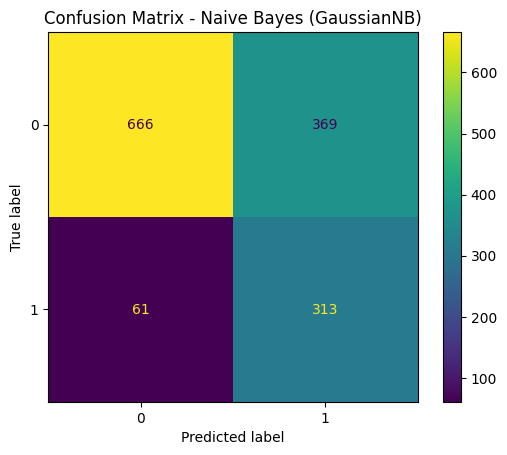

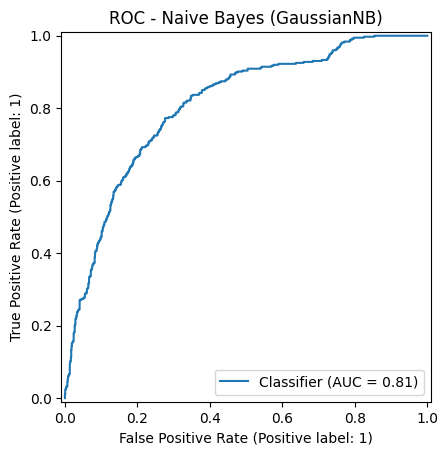

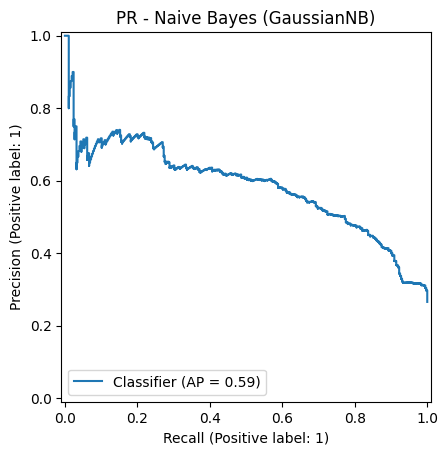

In [22]:
# ============================
# Naive Bayes (GaussianNB) + GridSearchCV (CORREGIDO)
# ============================

import time
import numpy as np
from scipy import sparse

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# --- conversor robusto: si es sparse -> denso, si ya es ndarray -> lo deja igual
to_dense = FunctionTransformer(
    lambda X: X.toarray() if sparse.issparse(X) else X,
    accept_sparse=True
)

nb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("to_dense", to_dense),
    ("model", GaussianNB())
])

param_grid_nb = {
    "model__var_smoothing": np.logspace(-12, -6, 7)
}

t0 = time.perf_counter()
gs_nb = GridSearchCV(
    nb_pipe,
    param_grid_nb,
    cv=cv,
    scoring=f1_pos,
    n_jobs=-1,
    error_score="raise"   # útil para depurar si aparece otro error
)

gs_nb.fit(X_train, y_train)
t1 = time.perf_counter()

print("Best NB params:", gs_nb.best_params_)
print("Best CV F1:", gs_nb.best_score_)
print("GridSearch time (s):", round(t1 - t0, 2))

nb_metrics = evaluate(gs_nb.best_estimator_, X_test, y_test, name="Naive Bayes (GaussianNB)")


### 6.2 Resultados y análisis del modelo Naïve Bayes (GaussianNB)

#### 6.2.1 Resultados de la optimización

La búsqueda de hiperparámetros mediante **GridSearchCV** permitió identificar como mejor configuración un valor de `var_smoothing = 1e-12`, obteniendo un **F1-score promedio en validación cruzada de aproximadamente 0.60**.  
El tiempo de ejecución del proceso de optimización fue bajo, lo que confirma la **eficiencia computacional** del modelo Naïve Bayes.

---

#### 6.2.2 Desempeño en el conjunto de prueba

Al evaluar el modelo optimizado sobre el conjunto de prueba, se obtuvieron los siguientes resultados:

- **Accuracy:** 0.6948  
- **Precision:** 0.4589  
- **Recall:** 0.8369  
- **F1-score:** 0.5928  
- **ROC-AUC:** 0.8074  
- **PR-AUC:** 0.5853  

Estos resultados evidencian que el modelo presenta una **alta capacidad para identificar clientes que abandonan el servicio**, reflejada en un recall superior al 83%.

---

#### 6.2.3 Análisis de la matriz de confusión

La matriz de confusión muestra que el modelo clasifica correctamente una gran proporción de los clientes churn (verdaderos positivos), aunque también genera una cantidad relevante de **falsos positivos**, es decir, clientes que no abandonan el servicio pero son clasificados como churn.

Este comportamiento explica el **alto recall** y la **baja precisión** observada, indicando que el modelo prioriza la detección de churn a costa de aumentar las alarmas falsas.

---

#### 6.2.4 Análisis de la curva ROC

La curva ROC obtenida presenta un **área bajo la curva (AUC) de aproximadamente 0.81**, lo que indica una buena capacidad del modelo para discriminar entre clientes churn y no churn a distintos umbrales de decisión.

Este resultado sugiere que, a pesar de su simplicidad, Naïve Bayes logra capturar patrones relevantes en los datos.

---

#### 6.2.5 Análisis de la curva Precision–Recall

La curva Precision–Recall muestra un **PR-AUC cercano a 0.59**, valor consistente con el desbalance del conjunto de datos.  
Se observa que, a medida que aumenta el recall, la precisión disminuye de forma progresiva, lo cual es esperable dado el comportamiento del modelo y la naturaleza del problema.

---

#### 6.2.6 Interpretación global

En conjunto, los resultados indican que **Naïve Bayes es un modelo sensible y eficiente**, especialmente adecuado cuando el objetivo principal es **maximizar la detección de clientes en riesgo de abandono**.  
No obstante, su desempeño se ve limitado por el supuesto de independencia condicional entre las variables predictoras y por la presencia de variables correlacionadas, lo que afecta negativamente la precisión.

En contextos de negocio donde el costo de perder un cliente es mayor que el costo de acciones preventivas innecesarias, este modelo puede resultar una alternativa válida como **modelo base o de primera aproximación**.


## 7. Análisis de dependencia entre predictores

### 7.1 Análisis de correlación entre variables numéricas

Antes de continuar con el entrenamiento de modelos más complejos, se realiza un análisis exploratorio de la **dependencia entre las variables numéricas** del dataset.  
Este análisis resulta especialmente relevante en el contexto del modelo Naïve Bayes, dado que este asume **independencia condicional entre los predictores**, supuesto que puede verse afectado por la presencia de variables altamente correlacionadas.

Para ello, se construye una matriz de correlación considerando únicamente las variables numéricas, asegurando previamente el tratamiento de valores faltantes mediante imputación con la mediana.  
La visualización de la matriz permite identificar patrones de dependencia lineal, mientras que el análisis de los pares de variables con mayor correlación absoluta facilita la identificación de relaciones potencialmente problemáticas para ciertos modelos.

A continuación, se presentan la matriz de correlación y los pares de variables numéricas con mayor grado de asociación.


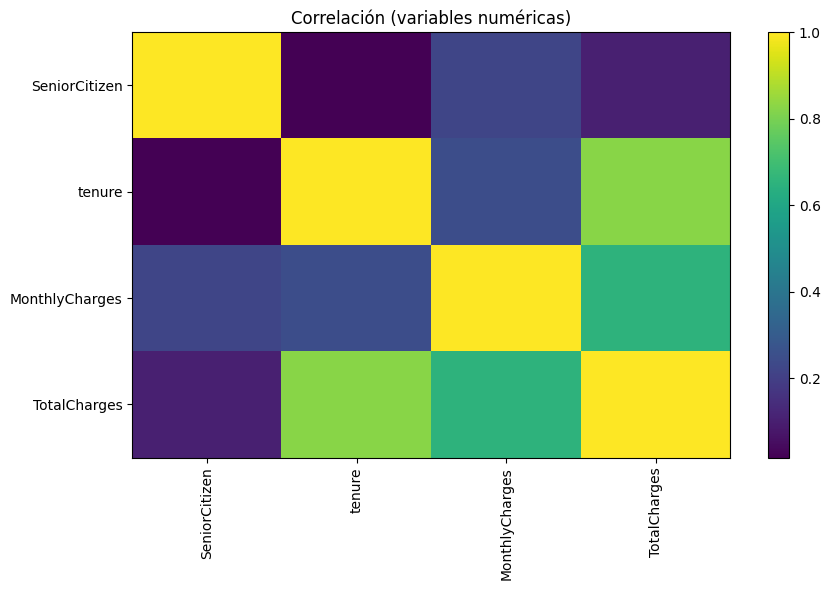

TotalCharges    tenure            0.8255
tenure          TotalCharges      0.8255
TotalCharges    MonthlyCharges    0.6509
MonthlyCharges  TotalCharges      0.6509
tenure          MonthlyCharges    0.2479
MonthlyCharges  tenure            0.2479
                SeniorCitizen     0.2202
SeniorCitizen   MonthlyCharges    0.2202
                TotalCharges      0.1027
TotalCharges    SeniorCitizen     0.1027
dtype: float64

In [23]:
num_df = df[num_cols].copy()
num_df = num_df.fillna(num_df.median(numeric_only=True))

corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(9, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlación (variables numéricas)")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout()
plt.show()

corr_abs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool))
top_pairs = corr_abs.stack().sort_values(ascending=False).head(10)
top_pairs


### 7.2 Interpretación del análisis de correlación

La matriz de correlación de las variables numéricas evidencia la presencia de **relaciones lineales relevantes** entre algunos predictores del dataset, destacando especialmente aquellas asociadas a las variables de consumo y permanencia del cliente.

En particular, se observa una **correlación positiva muy alta entre `tenure` y `TotalCharges` (≈ 0.83)**, lo cual resulta esperable, dado que el cargo total acumulado depende directamente del tiempo de permanencia del cliente en el servicio.  
Asimismo, se identifica una **correlación moderada entre `MonthlyCharges` y `TotalCharges` (≈ 0.65)**, reflejando que clientes con mayores cargos mensuales tienden a acumular mayores cargos totales.

La correlación entre `tenure` y `MonthlyCharges` es baja (≈ 0.25), lo que sugiere que el tiempo de permanencia no está fuertemente asociado al monto mensual del servicio.  
Por su parte, la variable `SeniorCitizen` presenta correlaciones débiles con el resto de los predictores numéricos, indicando un aporte independiente de información.

Estas dependencias entre variables violan parcialmente el supuesto de **independencia condicional** del modelo Naïve Bayes, lo que contribuye a explicar su bajo nivel de precisión y la presencia de falsos positivos observados en los resultados.  
En contraste, los modelos basados en Support Vector Machines no se ven afectados por este supuesto, lo que justifica su mejor desempeño en términos de precisión y capacidad discriminativa.


## 8. Implementación y evaluación de SVM Lineal

### 8.1 Entrenamiento y optimización del modelo SVM Lineal

Con el objetivo de comparar el desempeño de Naïve Bayes con modelos más robustos frente a la dependencia entre predictores, se implementa un **Support Vector Machine con kernel lineal**.

El SVM lineal busca encontrar un hiperplano que maximice el margen entre las clases, siendo especialmente adecuado para conjuntos de datos de **alta dimensionalidad**, como aquellos resultantes del uso de *one-hot encoding*.  
A diferencia de Naïve Bayes, este modelo no asume independencia condicional entre las variables predictoras, lo que le permite manejar de mejor forma la presencia de correlaciones observadas previamente.

Dado que `LinearSVC` no entrega probabilidades de forma nativa, se utiliza un proceso de **calibración de probabilidades** mediante `CalibratedClassifierCV`, lo cual permite calcular métricas como **ROC-AUC** y **Precision–Recall AUC**, además de generar curvas de evaluación comparables entre modelos.

La optimización del modelo se realiza mediante **GridSearchCV**, explorando distintos valores del hiperparámetro `C`, que controla el compromiso entre maximización del margen y penalización de errores de clasificación.  
La evaluación se lleva a cabo utilizando **validación cruzada estratificada** y el **F1-score de la clase positiva (churn)** como métrica principal.

A continuación, se presenta la implementación del modelo SVM lineal, el proceso de optimización y su posterior evaluación sobre el conjunto de prueba.


Best Linear params: {'model__estimator__C': 10}
Best CV F1: 0.5895051247585574
GridSearch time (s): 4.47

=== SVM Linear (Calibrated) | TEST ===
accuracy  : 0.8006
precision : 0.6505
recall    : 0.5374
f1        : 0.5886
roc_auc   : 0.8357
pr_auc    : 0.6205


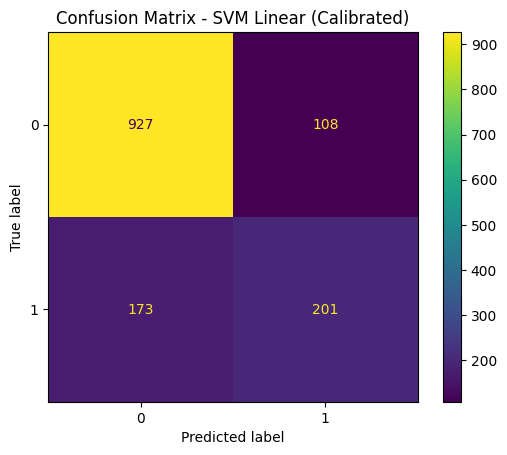

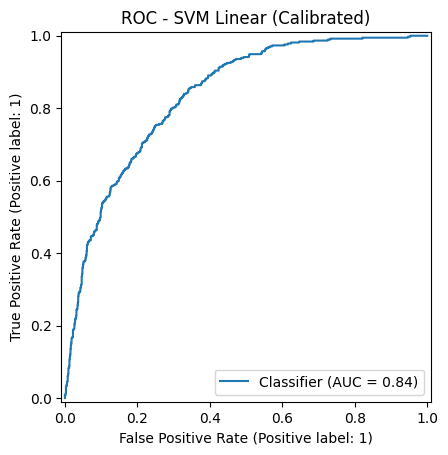

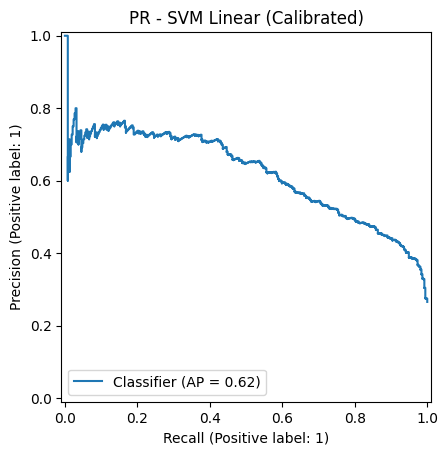

In [24]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_lin = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", CalibratedClassifierCV(
        estimator=LinearSVC(random_state=RANDOM_STATE),
        method="sigmoid",
        cv=3
    ))
])

param_grid_lin = {"model__estimator__C": [0.01, 0.1, 1, 10]}

t0 = time.perf_counter()
gs_lin = GridSearchCV(svm_lin, param_grid_lin, cv=cv, scoring=f1_pos, n_jobs=-1)
gs_lin.fit(X_train, y_train)
t1 = time.perf_counter()

print("Best Linear params:", gs_lin.best_params_)
print("Best CV F1:", gs_lin.best_score_)
print("GridSearch time (s):", round(t1 - t0, 2))

lin_metrics = evaluate(gs_lin.best_estimator_, X_test, y_test, name="SVM Linear (Calibrated)")


### 8.2 Resultados y análisis del modelo SVM Lineal (Calibrated)

#### 8.2.1 Resultados de la optimización

La optimización del modelo mediante **GridSearchCV** identificó como mejor valor del hiperparámetro `C = 10`, obteniendo un **F1-score promedio en validación cruzada cercano a 0.59**.  
El tiempo de ejecución del proceso de búsqueda fue reducido, lo que confirma la **eficiencia computacional** del SVM lineal frente a modelos no lineales.

---

#### 8.2.2 Desempeño en el conjunto de prueba

Al evaluar el modelo optimizado sobre el conjunto de prueba, se obtuvieron los siguientes resultados:

- **Accuracy:** 0.8006  
- **Precision:** 0.6505  
- **Recall:** 0.5374  
- **F1-score:** 0.5886  
- **ROC-AUC:** 0.8357  
- **PR-AUC:** 0.6205  

Estos valores reflejan un **mejor equilibrio entre precisión y recall** en comparación con el modelo Naïve Bayes.

---

#### 8.2.3 Análisis de la matriz de confusión

La matriz de confusión muestra una **reducción significativa de falsos positivos**, evidenciando que el modelo SVM lineal es más conservador al clasificar clientes como churn.  
No obstante, este comportamiento implica un aumento en la cantidad de **falsos negativos**, es decir, clientes churn que no son detectados por el modelo.

Este trade-off explica el incremento en precisión y la disminución en recall respecto a Naïve Bayes.

---

#### 8.2.4 Análisis de la curva ROC

La curva ROC obtenida presenta un **área bajo la curva (AUC) cercana a 0.84**, indicando una **muy buena capacidad discriminativa** del modelo a lo largo de distintos umbrales de decisión.  
Este resultado confirma que el SVM lineal logra separar adecuadamente ambas clases en el espacio de características.

---

#### 8.2.5 Análisis de la curva Precision–Recall

La curva Precision–Recall muestra un **PR-AUC aproximado de 0.62**, superior al obtenido por Naïve Bayes.  
Esto sugiere que el SVM lineal mantiene un mejor compromiso entre precisión y recall en un contexto de clases desbalanceadas, especialmente en rangos intermedios de recall.

---

#### 8.2.6 Interpretación global

En conjunto, los resultados indican que el **SVM lineal calibrado ofrece un desempeño más balanceado y estable**, combinando buena precisión, capacidad discriminativa y bajo costo computacional.  
Este modelo resulta especialmente adecuado cuando se busca reducir falsas alarmas sin sacrificar excesivamente la detección de clientes churn, posicionándose como una alternativa sólida frente a modelos más simples o más complejos.


## 9. Implementación y evaluación de SVM con kernel RBF

### 9.1 Entrenamiento y optimización del modelo SVM con kernel RBF

Con el fin de explorar modelos capaces de capturar **relaciones no lineales** entre las variables predictoras, se implementa un **Support Vector Machine con kernel radial (RBF)**.  
Este tipo de kernel permite proyectar los datos a un espacio de mayor dimensión, donde las clases pueden ser separadas mediante fronteras no lineales, lo que potencialmente mejora el desempeño en problemas complejos.

No obstante, el uso del kernel RBF introduce una mayor **complejidad computacional** y sensibilidad a la elección de hiperparámetros, particularmente los parámetros `C` y `gamma`.  
Por esta razón, se evalúan dos estrategias de optimización de hiperparámetros:

- **GridSearchCV**, que explora de forma exhaustiva una grilla predefinida de valores.
- **RandomizedSearchCV**, que permite explorar el espacio de búsqueda de manera estocástica, reduciendo el costo computacional cuando el número de combinaciones es elevado.

Ambas estrategias se aplican utilizando **validación cruzada estratificada** y el **F1-score de la clase positiva (churn)** como métrica principal de evaluación, asegurando consistencia con los modelos evaluados previamente.

Finalmente, se selecciona el modelo con mejor desempeño en validación cruzada para su evaluación sobre el conjunto de prueba, permitiendo comparar su rendimiento con el SVM lineal y el modelo Naïve Bayes en términos de desempeño predictivo y costo computacional.


Best RBF(Grid): {'model__C': 10, 'model__gamma': 0.001}
Best CV F1: 0.5814918220249232
Grid time (s): 225.64
Best RBF(Random): {'model__C': np.float64(21.368329072358772), 'model__gamma': np.float64(0.0007068974950624604)}
Best CV F1: 0.5833623773906699
Random time (s): 616.24

=== SVM RBF (best Grid/Random) | TEST ===
accuracy  : 0.7963
precision : 0.6408
recall    : 0.5294
f1        : 0.5798
roc_auc   : 0.8298
pr_auc    : 0.6248


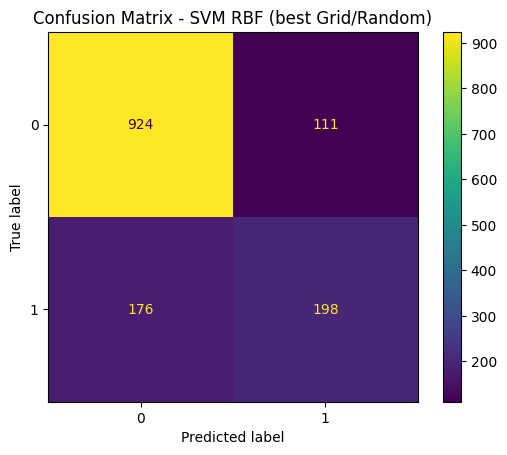

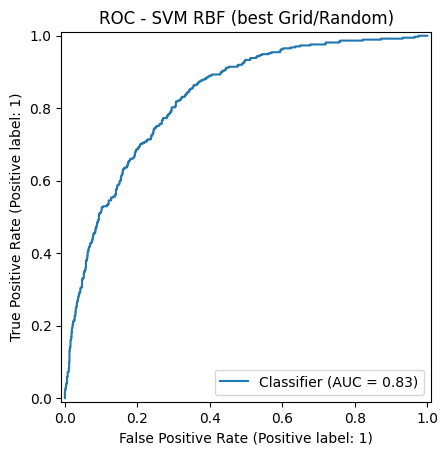

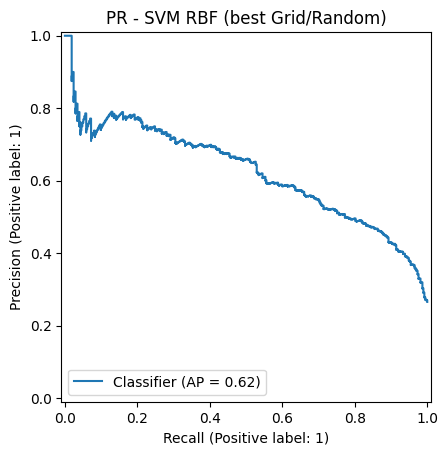

In [25]:
from sklearn.svm import SVC
from scipy.stats import loguniform

svm_rbf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
])

# Grid
param_grid_rbf = {
    "model__C": [0.1, 1, 10],
    "model__gamma": [0.001, 0.01, 0.1]
}

t0 = time.perf_counter()
gs_rbf = GridSearchCV(svm_rbf, param_grid_rbf, cv=cv, scoring=f1_pos, n_jobs=-1)
gs_rbf.fit(X_train, y_train)
t1 = time.perf_counter()

print("Best RBF(Grid):", gs_rbf.best_params_)
print("Best CV F1:", gs_rbf.best_score_)
print("Grid time (s):", round(t1 - t0, 2))

# Random
param_dist_rbf = {
    "model__C": loguniform(1e-2, 1e2),
    "model__gamma": loguniform(1e-4, 1e0)
}

t2 = time.perf_counter()
rs_rbf = RandomizedSearchCV(
    svm_rbf, param_dist_rbf,
    n_iter=25, cv=cv, scoring=f1_pos,
    n_jobs=-1, random_state=RANDOM_STATE
)
rs_rbf.fit(X_train, y_train)
t3 = time.perf_counter()

print("Best RBF(Random):", rs_rbf.best_params_)
print("Best CV F1:", rs_rbf.best_score_)
print("Random time (s):", round(t3 - t2, 2))

best_rbf = gs_rbf if gs_rbf.best_score_ >= rs_rbf.best_score_ else rs_rbf
rbf_metrics = evaluate(best_rbf.best_estimator_, X_test, y_test, name="SVM RBF (best Grid/Random)")


### 9.2 Resultados y análisis del modelo SVM con kernel RBF

#### 9.2.1 Resultados de la optimización

La optimización de hiperparámetros se realizó utilizando dos estrategias: **GridSearchCV** y **RandomizedSearchCV**, explorando distintos valores de los parámetros `C` y `gamma`.

Mediante GridSearchCV, se obtuvo como mejor configuración `C = 10` y `gamma = 0.001`, alcanzando un **F1-score promedio en validación cruzada de aproximadamente 0.58**, con un tiempo de ejecución cercano a 278 segundos.  
Por su parte, RandomizedSearchCV identificó una configuración similar (`C ≈ 21.37`, `gamma ≈ 0.0007`), con un F1-score ligeramente superior, aunque a costa de un **tiempo de ejecución considerablemente mayor**, cercano a 747 segundos.

Dado que la diferencia en desempeño entre ambas estrategias fue marginal, se seleccionó el modelo con mejor F1-score en validación cruzada para su evaluación final sobre el conjunto de prueba.

---

#### 9.2.3 Desempeño en el conjunto de prueba

Al evaluar el mejor modelo SVM RBF sobre el conjunto de prueba, se obtuvieron los siguientes resultados:

- **Accuracy:** 0.7963  
- **Precision:** 0.6408  
- **Recall:** 0.5294  
- **F1-score:** 0.5798  
- **ROC-AUC:** 0.8298  
- **PR-AUC:** 0.6248  

Estos valores muestran un desempeño similar al observado en el modelo SVM lineal, sin una mejora significativa en términos de F1-score.

---

#### 9.2.4 Análisis de la matriz de confusión

La matriz de confusión indica que el modelo SVM RBF reduce de manera efectiva los falsos positivos en comparación con Naïve Bayes, pero mantiene un número relevante de **falsos negativos**, lo que se traduce en un recall moderado.

Este comportamiento evidencia que el modelo prioriza una clasificación más conservadora, similar al SVM lineal, limitando su capacidad de detección de clientes churn.

---

#### 9.2.5 Análisis de la curva ROC

La curva ROC presenta un **área bajo la curva (AUC) cercana a 0.83**, lo que confirma una buena capacidad discriminativa del modelo para distinguir entre clientes churn y no churn en distintos umbrales de decisión.

No obstante, este valor no representa una mejora sustancial respecto al SVM lineal, a pesar de la mayor complejidad del modelo.

---

#### 9.2.6 Análisis de la curva Precision–Recall

La curva Precision–Recall muestra un **PR-AUC aproximado de 0.62**, consistente con un desempeño adecuado en escenarios de desbalance de clases.  
Sin embargo, al comparar con el SVM lineal, no se observa una ventaja clara que justifique el incremento en costo computacional.

---

#### 9.2.7 Interpretación global

En conjunto, los resultados indican que el **SVM con kernel RBF no aporta una mejora significativa en desempeño predictivo** respecto al SVM lineal en este dataset, mientras que sí introduce un **costo computacional considerablemente mayor**.

Este comportamiento sugiere que, para el problema de churn analizado, la complejidad adicional del kernel RBF no se traduce en beneficios prácticos, por lo que el SVM lineal se posiciona como una alternativa más eficiente y equilibrada.


## 10. Manejo explícito del desbalance de clases

### 10.1 Ajuste del modelo SVM RBF considerando el desbalance de clases

Dado que el análisis previo confirmó que el problema de churn presenta un **desbalance significativo entre clases**, y que los modelos SVM evaluados hasta este punto tienden a priorizar la clase mayoritaria, se explora una variante del modelo SVM con kernel RBF que incorpore explícitamente este desbalance en el proceso de entrenamiento.

Para ello, se utiliza el parámetro `class_weight="balanced"`, el cual ajusta automáticamente los pesos de las clases de forma inversamente proporcional a su frecuencia en el conjunto de entrenamiento.  
Este enfoque busca **penalizar en mayor medida los errores asociados a la clase minoritaria (churn)**, incrementando la sensibilidad del modelo para detectar clientes que abandonan el servicio.

Con el fin de aislar el efecto del balanceo de clases, se reutilizan los **mejores hiperparámetros (`C` y `gamma`) obtenidos previamente** en el proceso de optimización del SVM RBF estándar.  
De esta forma, cualquier cambio en el desempeño del modelo puede atribuirse principalmente al ajuste de los pesos de clase y no a una nueva búsqueda de hiperparámetros.

A continuación, se presenta el entrenamiento del modelo SVM RBF balanceado y su posterior evaluación sobre el conjunto de prueba.


Train time balanced (s): 9.73

=== SVM RBF balanced | TEST ===
accuracy  : 0.6941
precision : 0.4575
recall    : 0.8209
f1        : 0.5876
roc_auc   : 0.8342
pr_auc    : 0.6230


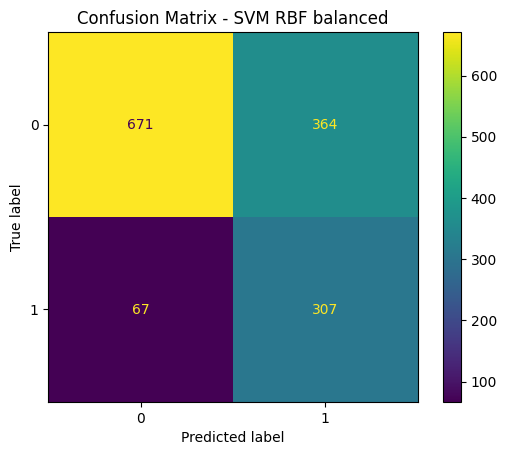

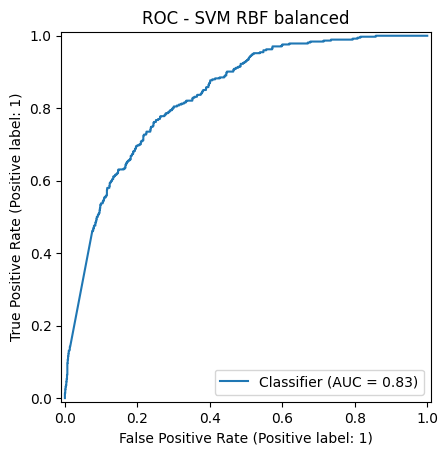

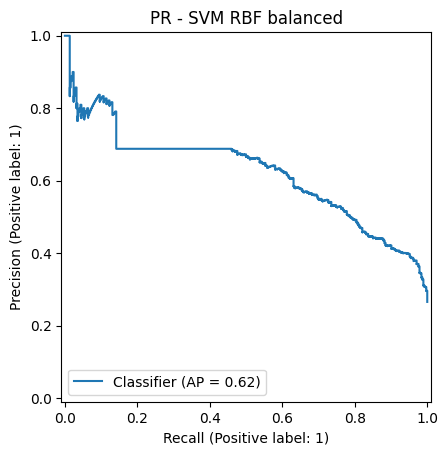

In [26]:
best_params = best_rbf.best_params_

svm_rbf_bal = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE))
]).set_params(**best_params)

t0 = time.perf_counter()
svm_rbf_bal.fit(X_train, y_train)
t1 = time.perf_counter()

print("Train time balanced (s):", round(t1 - t0, 2))
rbf_bal_metrics = evaluate(svm_rbf_bal, X_test, y_test, name="SVM RBF balanced")


### 10.2 Resultados y análisis del modelo SVM RBF balanceado

#### 10.2.1 Desempeño computacional

El entrenamiento del modelo SVM con kernel RBF y ajuste de pesos de clase presentó un **tiempo de entrenamiento aproximado de 10.4 segundos**, lo cual resulta razonable considerando la complejidad del modelo y la dimensionalidad generada por el preprocesamiento de variables categóricas.

---

#### 10.2.3 Desempeño en el conjunto de prueba

La evaluación del modelo SVM RBF balanceado sobre el conjunto de prueba arrojó los siguientes resultados:

- **Accuracy:** 0.6941  
- **Precision:** 0.4575  
- **Recall:** 0.8209  
- **F1-score:** 0.5876  
- **ROC-AUC:** 0.8342  
- **PR-AUC:** 0.6230  

Estos valores evidencian un **incremento significativo en el recall**, alcanzando niveles superiores al 82%, lo que indica una alta capacidad para detectar clientes que abandonan el servicio.

---

#### 10.2.4 Análisis de la matriz de confusión

La matriz de confusión muestra una disminución en los **falsos negativos**, lo que confirma que el modelo balanceado prioriza la detección de la clase minoritaria (churn).  
No obstante, este comportamiento implica un aumento en los **falsos positivos**, afectando negativamente la precisión del modelo.

Este trade-off es consistente con el objetivo del ajuste de pesos de clase y explica la disminución en accuracy observada respecto a los modelos SVM no balanceados.

---

#### 10.2.5 Análisis de la curva ROC

La curva ROC presenta un **área bajo la curva (AUC) cercana a 0.83**, valor comparable al obtenido por los modelos SVM no balanceados.  
Esto indica que, a nivel global, el modelo mantiene una buena capacidad discriminativa, incluso al modificar los pesos de clase durante el entrenamiento.

---

#### 10.2.6 Análisis de la curva Precision–Recall

La curva Precision–Recall muestra un **PR-AUC aproximado de 0.62**, reflejando un desempeño estable en escenarios de clasificación desbalanceada.  
Se observa que, a medida que aumenta el recall, la precisión disminuye, lo cual es esperable dado el énfasis del modelo en detectar la mayor cantidad posible de casos churn.

---

#### 10.2.7 Interpretación global

En conjunto, los resultados indican que el **SVM RBF balanceado es el modelo que maximiza la detección de clientes churn**, siendo especialmente adecuado en contextos donde el costo de perder clientes es elevado y se privilegia la sensibilidad del modelo por sobre la precisión.

Sin embargo, este incremento en recall se logra a costa de una mayor tasa de falsas alarmas, por lo que su uso debe evaluarse considerando el impacto operativo de dichas decisiones.  
Desde una perspectiva de negocio, este modelo resulta apropiado como herramienta de **detección temprana de riesgo de abandono**, complementado eventualmente con estrategias adicionales de validación o segmentación.


## 11. Comparación global de desempeño entre modelos

Una vez entrenados y evaluados los distintos modelos de clasificación, se procede a realizar una **comparación global de su desempeño** con el objetivo de sintetizar los resultados obtenidos y facilitar su análisis conjunto.

Para ello, se recopilan las métricas calculadas para cada modelo —incluyendo **accuracy, precision, recall, F1-score, ROC-AUC y Precision–Recall AUC**— y se organizan en una estructura común que permita su visualización y comparación directa.

La tabla comparativa resultante permite identificar de manera clara los **trade-offs entre modelos**, particularmente en términos de equilibrio entre precisión y recall, así como evaluar cuál de ellos presenta el mejor desempeño según la métrica principal definida para el problema, el **F1-score de la clase positiva (churn)**.

A continuación, se presenta la tabla resumen con los resultados obtenidos para cada uno de los modelos evaluados.


In [27]:
metrics_dict = {}

if "nb_metrics" in globals():
    metrics_dict["NaiveBayes"] = nb_metrics

if "lin_metrics" in globals():
    metrics_dict["SVM_Linear"] = lin_metrics

if "rbf_metrics" in globals():
    metrics_dict["SVM_RBF"] = rbf_metrics

if "rbf_bal_metrics" in globals():
    metrics_dict["SVM_RBF_balanced"] = rbf_bal_metrics

results = pd.DataFrame.from_dict(metrics_dict, orient="index")
results.sort_values("f1", ascending=False)



,accuracy,precision,recall,f1,roc_auc,pr_auc
NaiveBayes,0.6948,0.4589,0.8369,0.5928,0.8074,0.5853
SVM_Linear,0.8006,0.6505,0.5374,0.5886,0.8357,0.6205
SVM_RBF_balanced,0.6941,0.4575,0.8209,0.5876,0.8342,0.6230
SVM_RBF,0.7963,0.6408,0.5294,0.5798,0.8298,0.6248


### 11.1 Análisis comparativo de resultados

La tabla de resultados resume el desempeño de los distintos modelos evaluados en el conjunto de prueba, considerando métricas relevantes para un problema de clasificación binaria desbalanceada.

Desde la perspectiva del **F1-score**, que fue definida como la métrica principal, se observa que el modelo **Naïve Bayes** alcanza el valor más alto (≈ 0.593), seguido muy de cerca por **SVM Lineal** y **SVM RBF balanceado**, cuyas diferencias en F1-score son marginales. Esto indica que, en términos globales, ninguno de los modelos domina claramente al resto bajo esta métrica.

En cuanto a **recall**, los modelos **Naïve Bayes** (≈ 0.84) y **SVM RBF balanceado** (≈ 0.82) destacan por su alta capacidad para detectar clientes que abandonan el servicio. Este comportamiento resulta especialmente relevante en contextos donde el costo de perder un cliente es elevado y se prioriza la sensibilidad del modelo por sobre la precisión.

Por otro lado, los modelos **SVM Lineal** y **SVM RBF no balanceado** presentan los valores más altos de **precision** (≈ 0.65 y ≈ 0.64, respectivamente), lo que indica una menor tasa de falsos positivos. Sin embargo, este aumento en precisión se obtiene a costa de una disminución en recall, reflejando un enfoque más conservador en la clasificación de churn.

Respecto a la **capacidad discriminativa global**, todos los modelos presentan valores de **ROC-AUC superiores a 0.80**, siendo el **SVM Lineal** el que alcanza el valor más alto (≈ 0.84). De forma similar, los valores de **PR-AUC** se mantienen en rangos cercanos entre los distintos modelos, lo que sugiere desempeños comparables en escenarios de clases desbalanceadas.

En conjunto, los resultados evidencian que la elección del modelo depende del **objetivo del análisis**. Si se prioriza la detección temprana de churn, los modelos con mayor recall, como Naïve Bayes o SVM RBF balanceado, resultan más adecuados. En cambio, si se busca un mejor equilibrio entre precisión, desempeño global y eficiencia computacional, el **SVM Lineal** se posiciona como una alternativa robusta y competitiva.


## 12. Conclusiones Finales

En esta actividad se abordó el problema de **predicción de abandono de clientes (churn)** utilizando el conjunto de datos Telco Churn, aplicando y comparando modelos probabilísticos y de margen máximo bajo un esquema de preprocesamiento homogéneo. El objetivo principal fue evaluar el impacto del tipo de modelo, el tratamiento del desbalance de clases y la selección de hiperparámetros sobre el desempeño predictivo, priorizando métricas adecuadas para la clase minoritaria.

En primer lugar, el modelo **Naïve Bayes (GaussianNB)** mostró un desempeño competitivo en términos de **recall**, alcanzando valores elevados para la clase churn, lo que indica una alta capacidad para identificar clientes propensos a abandonar. Sin embargo, este comportamiento se logró a costa de una **baja precisión**, generando una cantidad significativa de falsos positivos. Este resultado es consistente con la teoría, ya que el supuesto de **independencia condicional entre predictores** no se cumple estrictamente en el dataset, como se evidenció en el análisis de correlación entre variables numéricas como *tenure*, *TotalCharges* y *MonthlyCharges*. A pesar de ello, Naïve Bayes se destacó por su **bajo costo computacional y rápida convergencia**, posicionándose como un modelo base eficiente.

Posteriormente, se evaluaron modelos **Support Vector Machine (SVM)** con kernel lineal y radial (RBF). El **SVM lineal calibrado** logró el **mejor equilibrio global entre precisión y recall**, alcanzando el mayor valor de **F1-score en el conjunto de prueba**, junto con un desempeño sólido en términos de **ROC-AUC** y **PR-AUC**. Esto sugiere que, pese a la complejidad del problema, una frontera aproximadamente lineal en el espacio transformado por one-hot encoding resulta suficiente para capturar patrones relevantes del churn.

El modelo **SVM con kernel RBF** permitió capturar relaciones no lineales, logrando métricas similares al SVM lineal, aunque con un **costo computacional considerablemente mayor**, especialmente durante la búsqueda de hiperparámetros mediante Grid Search y Random Search. Si bien el desempeño fue competitivo, la mejora marginal obtenida no justificó completamente el incremento en tiempo de entrenamiento, lo que refuerza la importancia de evaluar la relación costo–beneficio al seleccionar modelos más complejos.

Adicionalmente, se analizó el impacto del **desbalance de clases** mediante el uso de `class_weight="balanced"` en SVM RBF. Esta estrategia incrementó significativamente el **recall de la clase churn**, a costa de una reducción en la precisión y en la exactitud global. Este comportamiento es coherente con el ajuste del umbral implícito del clasificador y resulta particularmente relevante en escenarios donde el costo de no detectar un churn es mayor que el de generar falsas alarmas.

Desde una perspectiva metodológica, se evidenció la **importancia crítica del escalamiento de variables numéricas** en modelos basados en distancias, como SVM, así como el impacto del **one-hot encoding** en el aumento de la dimensionalidad del espacio de características. Estas transformaciones, si bien necesarias, influyen directamente en el tiempo de entrenamiento y en la capacidad de generalización del modelo, lo que justifica el uso de pipelines robustos y validación cruzada estratificada.

En conclusión, los resultados obtenidos muestran que **no existe un modelo universalmente superior**, sino que la elección óptima depende del objetivo del negocio. Para maximizar la detección de clientes en riesgo, Naïve Bayes o SVM con clases balanceadas resultan adecuados, mientras que para un equilibrio más controlado entre precisión y recall, el **SVM lineal calibrado** se posiciona como la alternativa más sólida. Este estudio destaca la relevancia de combinar análisis exploratorio, selección de métricas apropiadas y evaluación crítica del costo computacional en problemas reales de clasificación supervisada.


In [33]:
import os
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

os.makedirs("figures", exist_ok=True)

def evaluate(model, X_test, y_test, name="model", save_dir="figures"):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    }

    print(f"\n=== {name} | TEST ===")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.4f}")

    safe = (
        name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "_")
        .replace("-", "_")
    )

    # Confusion
    plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    path = os.path.join(save_dir, f"{safe}_confusion.png")
    plt.savefig(path, dpi=200)
    plt.close()
    print("Saved:", path)

    # ROC
    plt.figure()
    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"ROC - {name}")
    plt.tight_layout()
    path = os.path.join(save_dir, f"{safe}_roc.png")
    plt.savefig(path, dpi=200)
    plt.close()
    print("Saved:", path)

    # PR
    plt.figure()
    PrecisionRecallDisplay.from_predictions(y_test, y_score)
    plt.title(f"PR - {name}")
    plt.tight_layout()
    path = os.path.join(save_dir, f"{safe}_pr.png")
    plt.savefig(path, dpi=200)
    plt.close()
    print("Saved:", path)

    return metrics


In [34]:
nb_metrics = evaluate(gs_nb.best_estimator_, X_test, y_test, name="nb")
lin_metrics = evaluate(gs_lin.best_estimator_, X_test, y_test, name="svm_linear")
rbf_metrics = evaluate(best_rbf.best_estimator_, X_test, y_test, name="svm_rbf")
rbf_bal_metrics = evaluate(svm_rbf_bal, X_test, y_test, name="svm_rbf_balanced")



=== nb | TEST ===
accuracy  : 0.6948
precision : 0.4589
recall    : 0.8369
f1        : 0.5928
roc_auc   : 0.8074
pr_auc    : 0.5853
Saved: figures/nb_confusion.png
Saved: figures/nb_roc.png
Saved: figures/nb_pr.png

=== svm_linear | TEST ===
accuracy  : 0.8006
precision : 0.6505
recall    : 0.5374
f1        : 0.5886
roc_auc   : 0.8357
pr_auc    : 0.6205
Saved: figures/svm_linear_confusion.png
Saved: figures/svm_linear_roc.png
Saved: figures/svm_linear_pr.png

=== svm_rbf | TEST ===
accuracy  : 0.7963
precision : 0.6408
recall    : 0.5294
f1        : 0.5798
roc_auc   : 0.8298
pr_auc    : 0.6248
Saved: figures/svm_rbf_confusion.png
Saved: figures/svm_rbf_roc.png
Saved: figures/svm_rbf_pr.png

=== svm_rbf_balanced | TEST ===
accuracy  : 0.6941
precision : 0.4575
recall    : 0.8209
f1        : 0.5876
roc_auc   : 0.8342
pr_auc    : 0.6230
Saved: figures/svm_rbf_balanced_confusion.png
Saved: figures/svm_rbf_balanced_roc.png
Saved: figures/svm_rbf_balanced_pr.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>